In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
cwd = Path.cwd().resolve()
BASE_DIR = cwd.parent if cwd.name == "notebooks" else cwd


fleet_path = (BASE_DIR / "data" / "synthetic"/"fleet_rotary_blower_Finaldataset_2025.csv")
fleet_df = pd.read_csv(fleet_path)
fleet_df["date"] = pd.to_datetime(fleet_df["date"])
fleet_df.head()
fleet_df.info()
fleet_df.describe()
fleet_df.isna().sum()
fleet_df["maintenance_event"].value_counts()

<class 'pandas.DataFrame'>
RangeIndex: 4380 entries, 0 to 4379
Data columns (total 28 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   date                         4380 non-null   datetime64[us]
 1   amb_temp_max_c               4380 non-null   float64       
 2   amb_temp_min_c               4380 non-null   float64       
 3   amb_temp_avg_c               4380 non-null   float64       
 4   humidity                     4380 non-null   float64       
 5   wind_gust_kph                4380 non-null   float64       
 6   blower_id                    4380 non-null   str           
 7   site_id                      4380 non-null   str           
 8   operational_class            4380 non-null   str           
 9   max_op_ambient_temp_c        4380 non-null   float64       
 10  failure_threshold            4380 non-null   float64       
 11  max_op_rpm                   4380 non-null   int64    

maintenance_event
0    4343
1      37
Name: count, dtype: int64

In [3]:
fleet_df.groupby("blower_id")["maintenance_event"].sum()


blower_id
ZG150_B001    4
ZG150_B002    3
ZG150_B003    3
ZG150_B004    3
ZG200_B011    3
ZG200_B012    3
ZG200_B013    3
ZG200_B014    3
ZG250_B021    3
ZG250_B022    3
ZG250_B023    3
ZG250_B024    3
Name: maintenance_event, dtype: int64

In [4]:
fleet_df.groupby("blower_id")["degradation_index"].max()

blower_id
ZG150_B001    0.597100
ZG150_B002    0.644917
ZG150_B003    0.698111
ZG150_B004    0.624276
ZG200_B011    0.597861
ZG200_B012    0.670575
ZG200_B013    0.597798
ZG200_B014    0.669048
ZG250_B021    0.621681
ZG250_B022    0.659865
ZG250_B023    0.598437
ZG250_B024    0.618727
Name: degradation_index, dtype: float64

DISTRIBUTION ANALYSIS

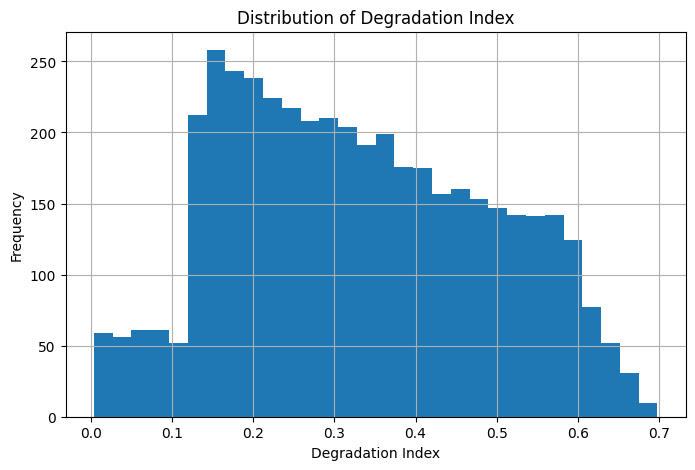

In [5]:
#Degradation Index Distribution
fig = plt.figure(figsize=(8,5))
plt.hist(
    fleet_df["degradation_index"],
    bins=30)
plt.title("Distribution of Degradation Index")
plt.xlabel("Degradation Index")
plt.ylabel("Frequency")
plt.grid(True)

fig.savefig(
    BASE_DIR / "outputs" / "final_figures" / "degradation_index_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

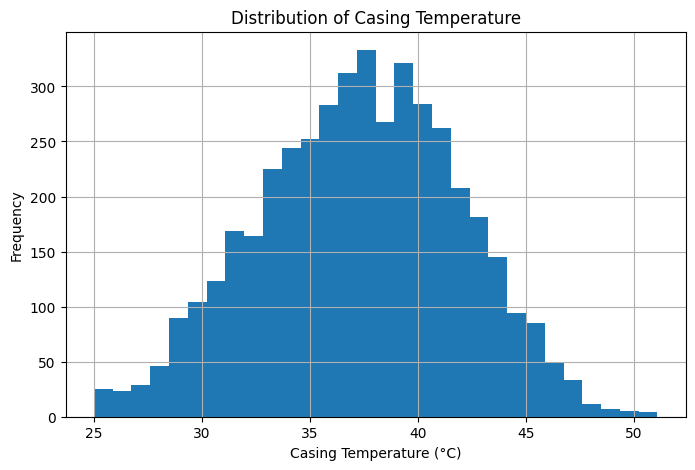

In [6]:
#temperature distribution
fig = plt.figure(figsize=(8,5))
plt.hist(
    fleet_df["casing_temperature_c"],
    bins=30
)
plt.title("Distribution of Casing Temperature")
plt.xlabel("Casing Temperature (°C)")
plt.ylabel("Frequency")
plt.grid(True)

fig.savefig(
    BASE_DIR / "outputs" / "final_figures" / "casing_temperature_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

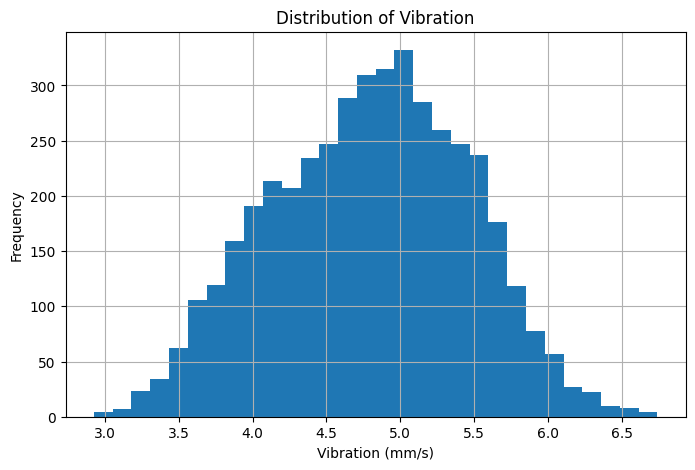

In [7]:
#Vibration distribution
fig = plt.figure(figsize=(8,5))
plt.hist(
    fleet_df["vibration_mm_s"],
    bins=30
)
plt.title("Distribution of Vibration")
plt.xlabel("Vibration (mm/s)")  
plt.ylabel("Frequency")
plt.grid(True)

fig.savefig(
    BASE_DIR / "outputs" / "final_figures" / "vibration_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

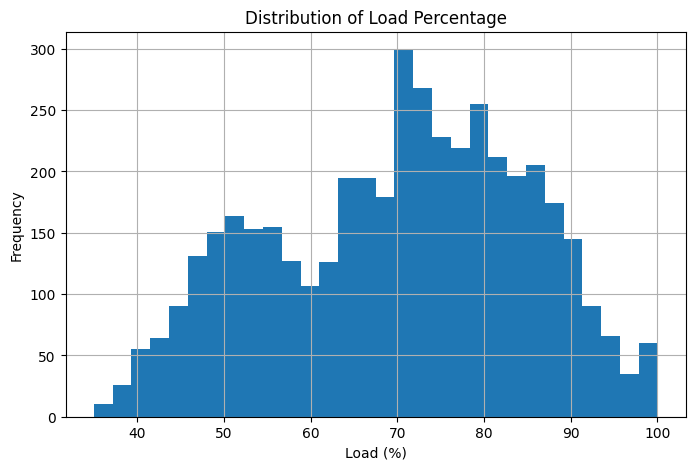

In [8]:
#Load distribution
fig = plt.figure(figsize=(8,5))

plt.hist(
    fleet_df["daily_load_percent"],
    bins=30
)
plt.title("Distribution of Load Percentage")
plt.xlabel("Load (%)")
plt.ylabel("Frequency")
plt.grid(True)

fig.savefig(
    BASE_DIR / "outputs" / "final_figures" / "load_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

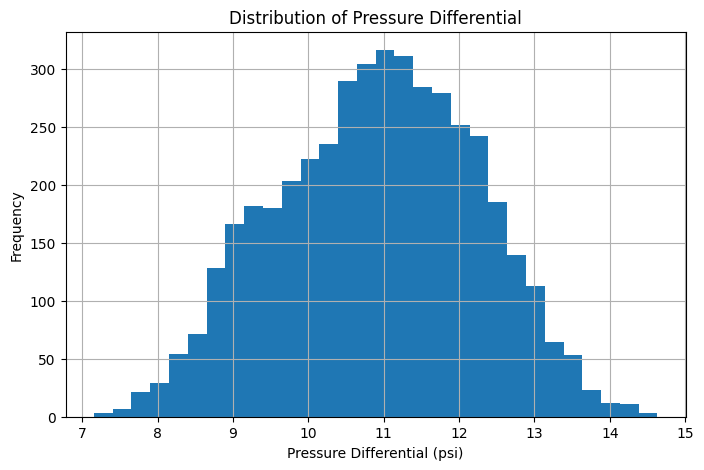

In [9]:
#Pressure distribution
fig = plt.figure(figsize=(8,5))

plt.hist(
    fleet_df["pressure_diff_psi"],
    bins=30
)
plt.title("Distribution of Pressure Differential")
plt.xlabel("Pressure Differential (psi)")
plt.ylabel("Frequency")
plt.grid(True)

fig.savefig(
    BASE_DIR / "outputs" / "final_figures" / "pressure_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

TIME-SERIES ANALYSIS

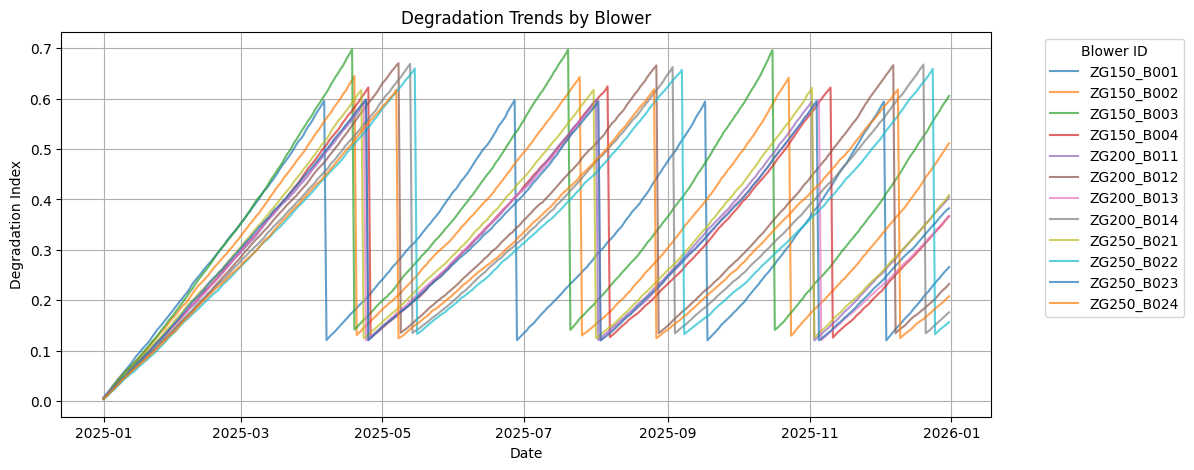

In [18]:
#degradation over time
fig = plt.figure(figsize=(12,5))

for blower in fleet_df["blower_id"].unique():
    subset = fleet_df[
        fleet_df["blower_id"] == blower
    ]
    plt.plot(
        subset["date"],
        subset["degradation_index"],
        alpha=0.7
    )
plt.title("Degradation Trends by Blower")
plt.xlabel("Date")
plt.ylabel("Degradation Index")
plt.legend(fleet_df["blower_id"].unique(), title="Blower ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)

fig.savefig(
    BASE_DIR / "outputs" / "final_figures" / "degradation_trends_by_blower.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

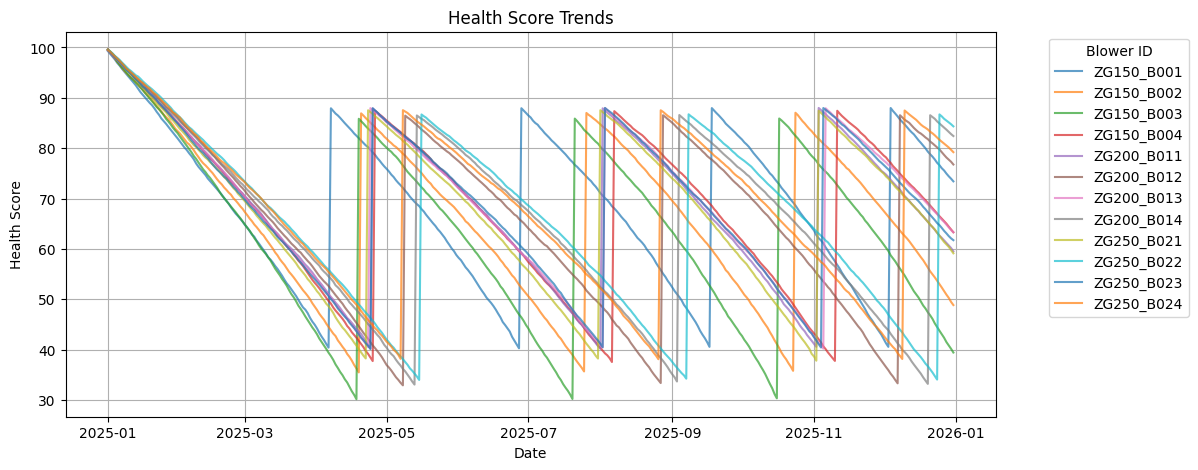

In [19]:
#Health score over time
fig = plt.figure(figsize=(12,5))

for blower in fleet_df["blower_id"].unique():
    subset = fleet_df[
        fleet_df["blower_id"] == blower
    ]
    plt.plot(
        subset["date"],
        subset["health_score"],
        alpha=0.7
    )
plt.title("Health Score Trends")
plt.legend(fleet_df["blower_id"].unique(), title="Blower ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("Date")
plt.ylabel("Health Score")
plt.grid(True)

fig.savefig(
    BASE_DIR / "outputs" / "final_figures" / "health_score_trends_by_blower.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

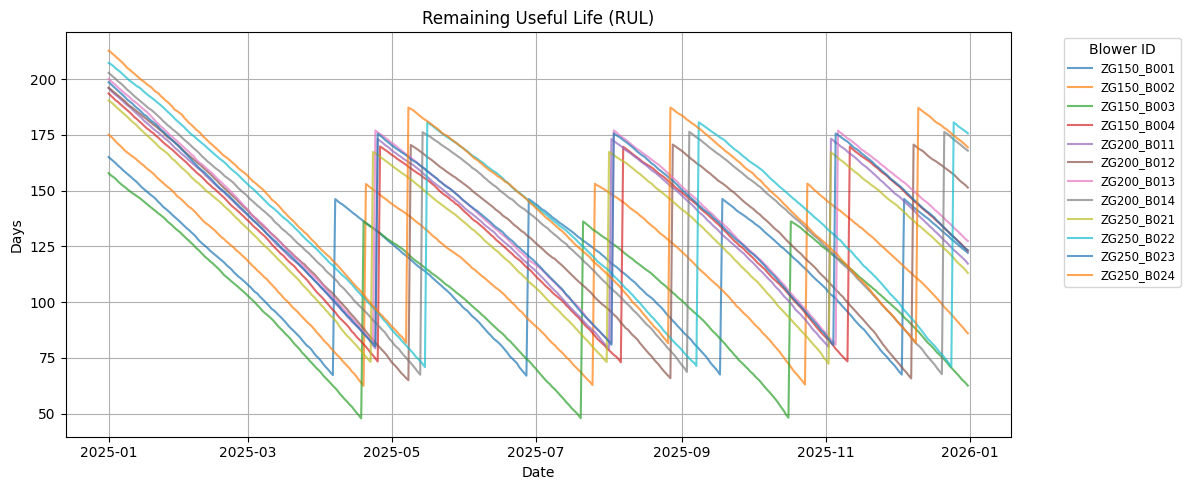

In [12]:
#RUL over time
fig = plt.figure(figsize=(12,5))

for blower in fleet_df["blower_id"].unique():
    subset = fleet_df[fleet_df["blower_id"] == blower].sort_values("date")
    plt.plot(
        subset["date"],
        subset["RUL_days"],
        alpha=0.7,
        label=str(blower)
    )
plt.title("Remaining Useful Life (RUL)")
plt.xlabel("Date")
plt.ylabel("Days")
plt.legend(title="Blower ID", fontsize="small", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()

fig.savefig(
    BASE_DIR / "outputs" / "final_figures" / "RUL_trends_by_blower.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

SITE COMPARISONS

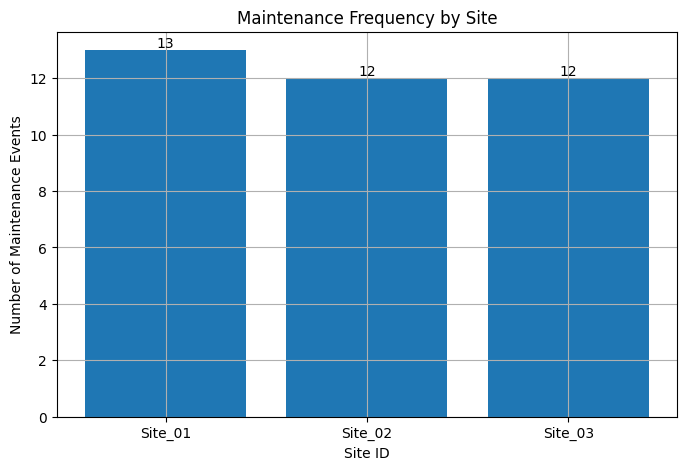

In [13]:
#Maintenance frequency by site
site_maintenance = (
    fleet_df.groupby("site_id")["maintenance_event"]
    .sum()
)


#histogram of maintenance frequency by site
fig = plt.figure(figsize=(8,5))
plt.bar(site_maintenance.index, site_maintenance.values)
ax = plt.gca()
ax.bar_label(ax.containers[0], label_type='edge')
plt.title("Maintenance Frequency by Site")
plt.xlabel("Site ID")
plt.ylabel("Number of Maintenance Events")
plt.grid(True)

fig.savefig(
    BASE_DIR / "outputs" / "final_figures" / "maintenance_frequency_by_site.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

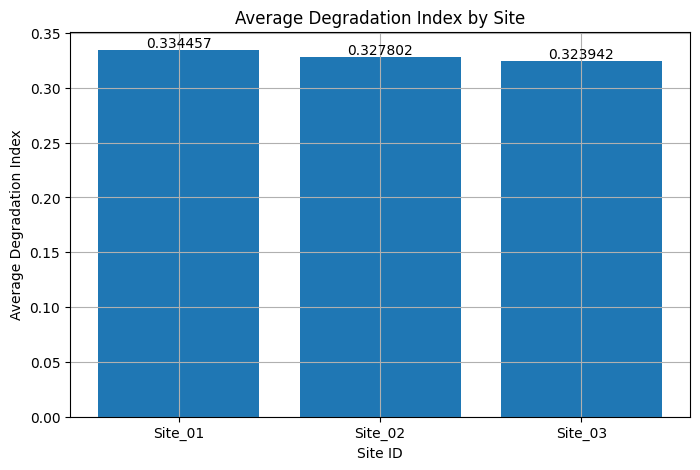

In [14]:
site_degradation = (
    fleet_df.groupby("site_id")["degradation_index"]
    .mean()
)

#histogram of average degradation index by site
fig = plt.figure(figsize=(8,5))
plt.bar(site_degradation.index, site_degradation.values)
ax = plt.gca()
ax.bar_label(ax.containers[0], label_type='edge')
plt.title("Average Degradation Index by Site")
plt.xlabel("Site ID")
plt.ylabel("Average Degradation Index")
plt.grid(True)

fig.savefig(
    BASE_DIR / "outputs" / "final_figures" / "average_degradation_index_by_site.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

OPERATIONAL CLASS COMPARISON

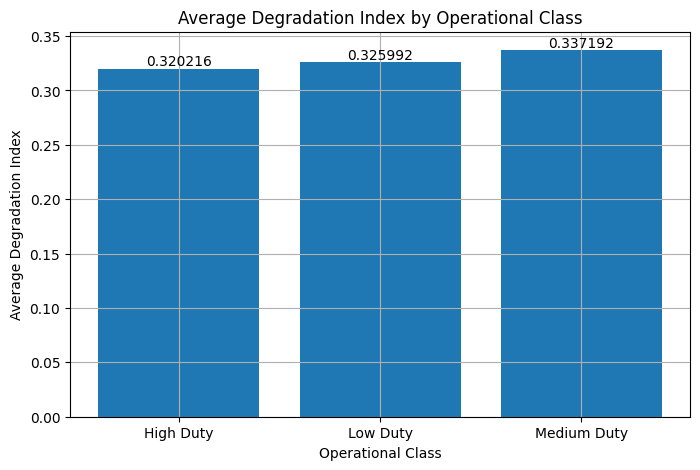

In [15]:
#Average degradation by operational class
class_degradation = (
    fleet_df.groupby("operational_class")["degradation_index"]
    .mean()
)

fig = plt.figure(figsize=(8,5))
plt.bar(class_degradation.index, class_degradation.values)
ax = plt.gca()
ax.bar_label(ax.containers[0], label_type='edge')
plt.title("Average Degradation Index by Operational Class")
plt.xlabel("Operational Class")
plt.ylabel("Average Degradation Index")
plt.grid(True)

fig.savefig(
    BASE_DIR / "outputs" / "final_figures" / "average_degradation_by_class.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

Correlation matrix

In [16]:
from pandas.io.formats.style import Styler

correlation_columns = [
    "amb_temp_avg_c",
    "humidity",
    "dust_index",
    "daily_op_hours",
    "daily_load_percent",
    "pressure_diff_psi",
    "casing_temperature_c",
    "vibration_mm_s",
    "degradation_index",
    "daily_degradation",
    "health_score",
    "RUL_days"
]

correlation_matrix = (
    fleet_df[correlation_columns]
    .corr()
)

correlation_matrix.style.background_gradient(cmap="coolwarm", vmin=-1, vmax=1)

,amb_temp_avg_c,humidity,dust_index,daily_op_hours,daily_load_percent,pressure_diff_psi,casing_temperature_c,vibration_mm_s,degradation_index,daily_degradation,health_score,RUL_days
amb_temp_avg_c,1.000000,-0.011435,0.063662,-0.004783,-0.006386,0.010422,0.781890,-0.011251,-0.191405,0.141489,0.191405,0.181827
humidity,-0.011435,1.000000,-0.454525,-0.002336,0.000495,-0.111049,-0.028635,-0.067813,-0.126722,-0.020510,0.126722,0.116655
dust_index,0.063662,-0.454525,1.000000,-0.003451,0.004086,0.259224,0.098152,0.105958,0.047693,0.063896,-0.047693,-0.044777
daily_op_hours,-0.004783,-0.002336,-0.003451,1.000000,0.854581,0.762406,0.447505,0.745735,-0.017872,0.207653,0.017872,-0.160032
daily_load_percent,-0.006386,0.000495,0.004086,0.854581,1.000000,0.892535,0.522658,0.853766,-0.023464,0.267408,0.023464,-0.141955
pressure_diff_psi,0.010422,-0.111049,0.259224,0.762406,0.892535,1.000000,0.512800,0.819127,-0.007491,0.275996,0.007491,-0.137981
casing_temperature_c,0.781890,-0.028635,0.098152,0.447505,0.522658,0.512800,1.000000,0.448361,-0.156457,0.276662,0.156457,0.066141
vibration_mm_s,-0.011251,-0.067813,0.105958,0.745735,0.853766,0.819127,0.448361,1.000000,0.040218,0.324868,-0.040218,-0.182844
degradation_index,-0.191405,-0.126722,0.047693,-0.017872,-0.023464,-0.007491,-0.156457,0.040218,1.000000,0.544551,-1.000000,-0.942659
daily_degradation,0.141489,-0.020510,0.063896,0.207653,0.267408,0.275996,0.276662,0.324868,0.544551,1.000000,-0.544551,-0.641341


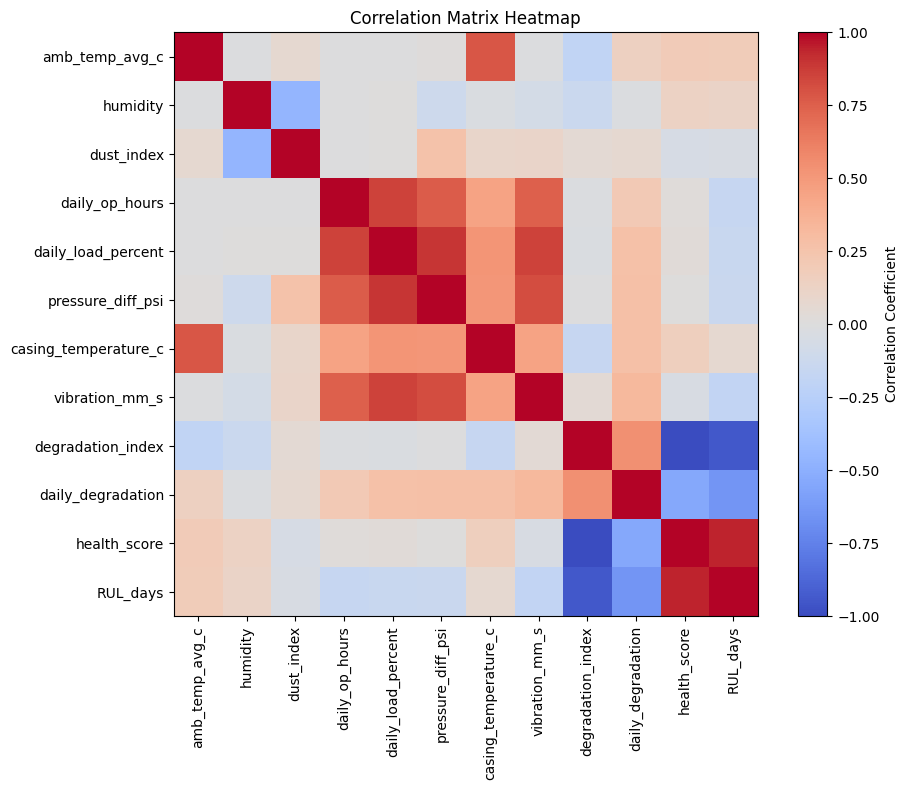

In [17]:
correlation_matrix["degradation_index"]\
    .sort_values(ascending=False)

#plot correlation matrix as heatmap
fig = plt.figure(figsize=(10,8))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation Coefficient")   
plt.xticks(range(len(correlation_columns)), correlation_columns, rotation=90)
plt.yticks(range(len(correlation_columns)), correlation_columns)
plt.title("Correlation Matrix Heatmap")
plt.tight_layout()

fig.savefig(
    BASE_DIR / "outputs" / "final_figures" / "correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()